"""
================================================================================
ESERCIZIO COMPLETO PANDAS: ANALISI DATI AZIENDALI
================================================================================
Professore: Corso Analisi Dati Avanzata

SCENARIO:
Sei il Data Analyst di "TechStore Italia", una catena di negozi di elettronica.
Il CEO ti ha chiesto di analizzare le vendite dell'ultimo trimestre per 
identificare trend, performance dei prodotti e comportamento dei clienti.

HAI A DISPOSIZIONE 2 DATABASE:
1. Database Vendite (vendite.csv)
2. Database Prodotti (prodotti.csv)

COMPETENZE DA DIMOSTRARE:
✓ Caricamento e creazione database
✓ Merge/Join tra dataframe
✓ Analisi esplorativa (EDA)
✓ Selezione con loc e iloc
✓ Filtraggio con query()
✓ Aggregazioni e statistiche

================================================================================
"""

In [18]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt


In [8]:
df_prodotti=pd.read_csv("database_prodotti.csv")
df_vendite=pd.read_csv("database_vendite.csv")

In [56]:
df_resoconto=df_vendite.merge(
    df_prodotti,
    on=["ID_Prodotto"],
    how="left"
)

df_resoconto["Totale_spesa"] = df_resoconto["Quantità"] * df_resoconto["Prezzo"]

df_resoconto

,ID_Vendita,Data,ID_Prodotto,ID_Cliente,Quantità,ID_Negozio,Nome_Prodotto,Categoria,Prezzo,Fornitore,Margine_Percentuale,Totale_spesa
0,1250,2024-01-01,105,9,7,5,MacBook Air M3,Laptop,1299,Apple Inc.,38,9093
1,1105,2024-01-01,107,29,6,2,HP Spectre x360,Laptop,1199,HP Inc.,33,7194
2,1136,2024-01-01,115,30,10,4,Logitech MX Master,Accessori,119,Logitech,40,1190
3,1474,2024-01-01,119,25,3,5,JBL Flip 6,Audio,129,JBL,42,387
4,1438,2024-01-01,103,35,1,2,Google Pixel 8,Smartphone,699,Google LLC,30,699
...,...,...,...,...,...,...,...,...,...,...,...,...
495,1360,2024-03-30,106,24,7,1,Dell XPS 15,Laptop,1499,Dell Technologies,35,10493
496,1075,2024-03-30,109,40,8,2,ASUS ZenBook,Laptop,999,ASUS,32,7992
497,1215,2024-03-30,108,20,1,1,Lenovo ThinkPad X1,Laptop,1399,Lenovo,34,1399
498,1427,2024-03-30,103,29,6,2,Google Pixel 8,Smartphone,699,Google LLC,30,4194


In [51]:
print("="*80)
print("PRIME 10 RIGHE")
print("="*80)
display(df_resoconto.head(10))

print("="*80)
print("ULTIME 10 RIGHE")
print("="*80)
display(df_resoconto.tail(10))


print("="*80)
print("10 RIGHE SCELTE CASUALMENTE")
print("="*80)
display(df_resoconto.sample(10))


PRIME 10 RIGHE


,ID_Vendita,Data,ID_Prodotto,ID_Cliente,Quantità,ID_Negozio,Nome_Prodotto,Categoria,Prezzo,Fornitore,Margine_Percentuale,Totale spesa
0,1250,2024-01-01,105,9,7,5,MacBook Air M3,Laptop,1299,Apple Inc.,38,9093
1,1105,2024-01-01,107,29,6,2,HP Spectre x360,Laptop,1199,HP Inc.,33,7194
2,1136,2024-01-01,115,30,10,4,Logitech MX Master,Accessori,119,Logitech,40,1190
3,1474,2024-01-01,119,25,3,5,JBL Flip 6,Audio,129,JBL,42,387
4,1438,2024-01-01,103,35,1,2,Google Pixel 8,Smartphone,699,Google LLC,30,699
5,1434,2024-01-01,109,45,10,3,ASUS ZenBook,Laptop,999,ASUS,32,9990
6,1210,2024-01-01,104,18,8,4,OnePlus 12,Smartphone,799,OnePlus,28,6392
7,1432,2024-01-01,114,33,7,1,Magic Mouse,Accessori,89,Apple Inc.,45,623
8,1177,2024-01-01,101,37,4,4,iPhone 15,Smartphone,999,Apple Inc.,35,3996
9,1263,2024-01-01,111,18,10,4,Samsung Galaxy Tab S9,Tablet,849,Samsung Electronics,33,8490


ULTIME 10 RIGHE


,ID_Vendita,Data,ID_Prodotto,ID_Cliente,Quantità,ID_Negozio,Nome_Prodotto,Categoria,Prezzo,Fornitore,Margine_Percentuale,Totale spesa
490,1053,2024-03-30,120,8,6,1,HomePod mini,Audio,99,Apple Inc.,40,594
491,1240,2024-03-30,115,17,2,1,Logitech MX Master,Accessori,119,Logitech,40,238
492,1260,2024-03-30,102,37,6,4,Samsung Galaxy S24,Smartphone,899,Samsung Electronics,32,5394
493,1138,2024-03-30,117,40,10,1,Sony WH-1000XM5,Audio,399,Sony,38,3990
494,1144,2024-03-30,111,50,9,3,Samsung Galaxy Tab S9,Tablet,849,Samsung Electronics,33,7641
495,1360,2024-03-30,106,24,7,1,Dell XPS 15,Laptop,1499,Dell Technologies,35,10493
496,1075,2024-03-30,109,40,8,2,ASUS ZenBook,Laptop,999,ASUS,32,7992
497,1215,2024-03-30,108,20,1,1,Lenovo ThinkPad X1,Laptop,1399,Lenovo,34,1399
498,1427,2024-03-30,103,29,6,2,Google Pixel 8,Smartphone,699,Google LLC,30,4194
499,1460,2024-03-30,119,39,9,5,JBL Flip 6,Audio,129,JBL,42,1161


10 RIGHE SCELTE CASUALMENTE


,ID_Vendita,Data,ID_Prodotto,ID_Cliente,Quantità,ID_Negozio,Nome_Prodotto,Categoria,Prezzo,Fornitore,Margine_Percentuale,Totale spesa
330,1205,2024-02-28,114,19,6,2,Magic Mouse,Accessori,89,Apple Inc.,45,534
451,1249,2024-03-22,117,39,9,2,Sony WH-1000XM5,Audio,399,Sony,38,3591
432,1180,2024-03-17,115,28,5,1,Logitech MX Master,Accessori,119,Logitech,40,595
15,1068,2024-01-02,105,37,8,1,MacBook Air M3,Laptop,1299,Apple Inc.,38,10392
232,1257,2024-02-11,105,45,7,4,MacBook Air M3,Laptop,1299,Apple Inc.,38,9093
61,1467,2024-01-10,115,45,6,3,Logitech MX Master,Accessori,119,Logitech,40,714
238,1498,2024-02-12,101,8,3,3,iPhone 15,Smartphone,999,Apple Inc.,35,2997
204,1327,2024-02-04,107,26,5,4,HP Spectre x360,Laptop,1199,HP Inc.,33,5995
251,1099,2024-02-14,113,25,9,5,AirPods Pro 2,Accessori,279,Apple Inc.,42,2511
469,1085,2024-03-27,109,25,10,2,ASUS ZenBook,Laptop,999,ASUS,32,9990


In [52]:
print("="*80)
print("INFORMAZIONI SUL DATABASE")
print("="*80)

df_resoconto.info()

INFORMAZIONI SUL DATABASE
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID_Vendita           500 non-null    int64 
 1   Data                 500 non-null    object
 2   ID_Prodotto          500 non-null    int64 
 3   ID_Cliente           500 non-null    int64 
 4   Quantità             500 non-null    int64 
 5   ID_Negozio           500 non-null    int64 
 6   Nome_Prodotto        500 non-null    object
 7   Categoria            500 non-null    object
 8   Prezzo               500 non-null    int64 
 9   Fornitore            500 non-null    object
 10  Margine_Percentuale  500 non-null    int64 
 11  Totale spesa         500 non-null    int64 
dtypes: int64(8), object(4)
memory usage: 47.0+ KB


In [53]:
print("="*80)
print("DESCRIZIONE DATABASE")
print("="*80)

df_resoconto.describe()

DESCRIZIONE DATABASE


,ID_Vendita,ID_Prodotto,ID_Cliente,Quantità,ID_Negozio,Prezzo,Margine_Percentuale,Totale spesa
count,500.000000,500.00000,500.000000,500.00000,500.000000,500.000000,500.00000,500.000000
mean,1250.500000,110.23200,26.340000,5.42600,3.094000,728.540000,36.55600,3933.614000
std,144.481833,5.81324,14.225228,2.94174,1.425914,474.225863,4.88042,3491.480754
min,1001.000000,101.00000,1.000000,1.00000,1.000000,49.000000,28.00000,89.000000
25%,1125.750000,105.00000,14.750000,3.00000,2.000000,279.000000,33.00000,880.500000
50%,1250.500000,110.00000,26.000000,5.00000,3.000000,799.000000,36.00000,2796.000000
75%,1375.250000,115.00000,39.000000,8.00000,4.000000,1099.000000,40.00000,6417.750000
max,1500.000000,120.00000,50.000000,10.00000,5.000000,1499.000000,50.00000,14990.000000


DISTRIBUZIONE PRODOTTO
Categoria
Laptop        131
Smartphone    105
Audio         101
Accessori      98
Tablet         65
Name: count, dtype: int64
PERCENTUALI
Categoria
Laptop        26.2%
Smartphone    21.0%
Audio         20.2%
Accessori     19.6%
Tablet        13.0%
Name: proportion, dtype: object


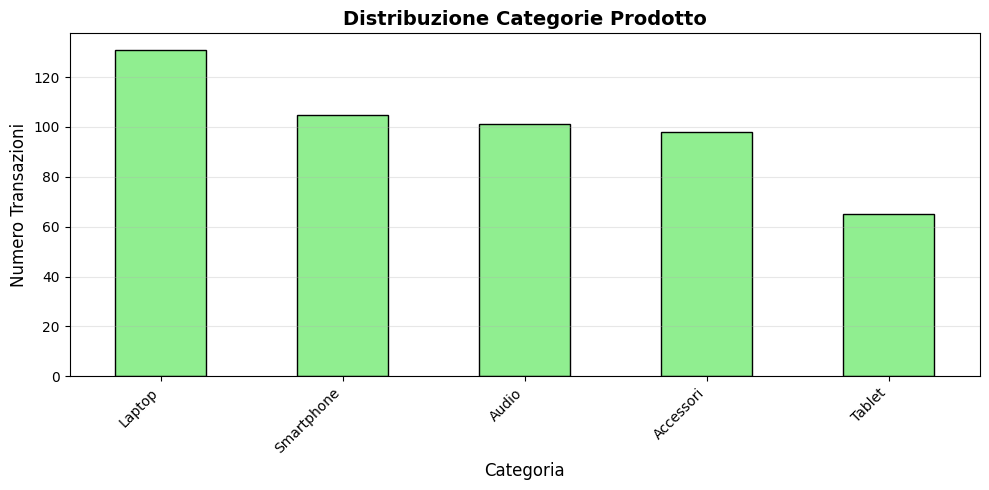

In [46]:
print("="*80)
print("DISTRIBUZIONE PRODOTTO")
print("="*80)

print(df_resoconto["Categoria"].value_counts())

print("="*80)
print("PERCENTUALI")

print(df_resoconto["Categoria"].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

plt.figure(figsize=(10, 5))
df_resoconto['Categoria'].value_counts().plot(kind='bar', color='lightgreen', edgecolor='black')
plt.title('Distribuzione Categorie Prodotto', fontsize=14, fontweight='bold')
plt.xlabel('Categoria', fontsize=12)
plt.ylabel('Numero Transazioni', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [47]:
print("="*80)
print("ANALISI DUPLICATI")
print("="*80)

n_duplicati=df_resoconto.duplicated().sum()
print(f"Numero di righe duplicate: {n_duplicati}")
print(f"Percentuale: {(n_duplicati/len(df_resoconto)*100):.2f}%")

ANALISI DUPLICATI
Numero di righe duplicate: 0
Percentuale: 0.00%


In [58]:
print("="*80)
print("IDENTIFICAZIONE OUTLIER")
print("="*80)

totale=df_resoconto["Totale_spesa"].dropna()

Q1=totale.quantile(0.25)
Q3=totale.quantile(0.75)

IQR=Q3-Q1

lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR

print(f"Q1 (25° percentile): €{Q1:.2f}")
print(f"Q3 (75° percentile): €{Q3:.2f}")
print(f"IQR: €{IQR:.2f}")
print(f"\nSoglie outlier:")
print(f"  Inferiore: €{lower_bound:.2f}")
print(f"  Superiore: €{upper_bound:.2f}")

outliers = df_resoconto.loc[(df_resoconto['Totale_spesa'] < lower_bound) | (df_resoconto['Totale_spesa'] > upper_bound)]
display(outliers[["ID_Vendita","Categoria","Quantità","Prezzo","Totale_spesa"]])
print(f"\n🎯 Outlier trovati: {len(outliers)} ({len(outliers)/len(df_resoconto)*100:.2f}%)")

IDENTIFICAZIONE OUTLIER
Q1 (25° percentile): €880.50
Q3 (75° percentile): €6417.75
IQR: €5537.25

Soglie outlier:
  Inferiore: €-7425.38
  Superiore: €14723.62


,ID_Vendita,Categoria,Quantità,Prezzo,Totale_spesa
98,1361,Laptop,10,1499,14990
449,1090,Laptop,10,1499,14990



🎯 Outlier trovati: 2 (0.40%)


PATTERN TEMPORALI


,Totale_spesa,ID_Cliente,Quantità
Mese,,,
1,679187,173,963
2,637417,172,873
3,650203,155,877


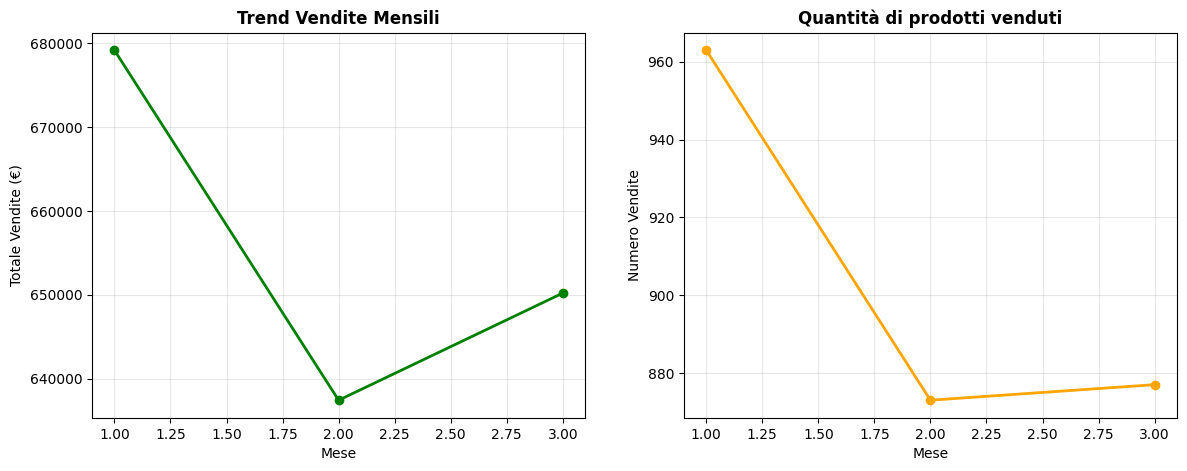

In [68]:
print("="*80)
print("PATTERN TEMPORALI")
print("="*80)

df_resoconto["Data"]=pd.to_datetime(df_resoconto["Data"])

df_resoconto['Mese'] = df_resoconto['Data'].dt.month
df_resoconto['Nome_Mese'] = df_resoconto['Data'].dt.month_name()

monthly_sales = df_resoconto.groupby('Mese').agg({
    'Totale_spesa': 'sum',
    'ID_Cliente': 'count',
    'Quantità':'sum'
}).rename(columns={'Cliente_ID': 'N_Ordini'})


display(monthly_sales)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
monthly_sales['Totale_spesa'].plot(kind='line', ax=ax1, marker='o', color='green', linewidth=2)
ax1.set_title('Trend Vendite Mensili', fontweight='bold')
ax1.set_xlabel('Mese')
ax1.set_ylabel('Totale Vendite (€)')
ax1.grid(True, alpha=0.3)


monthly_sales['Quantità'].plot(kind='line', ax=ax2, marker='o', color='orange', linewidth=2)
ax2.set_title('Quantità di prodotti venduti', fontweight='bold')
ax2.set_xlabel('Mese')
ax2.set_ylabel('Numero Vendite')
ax2.grid(True, alpha=0.3)



PRODOTTI PIU COSTOSI MAGGIORMENTE ACQUISTATI NELL'ULTIMO MESE


,ID_Vendita,Data,ID_Prodotto,ID_Cliente,Quantità,ID_Negozio,Nome_Prodotto,Categoria,Prezzo,Fornitore,Margine_Percentuale,Totale_spesa,Mese,Nome_Mese
345,1440,2024-03-01,108,34,8,4,Lenovo ThinkPad X1,Laptop,1399,Lenovo,34,11192,3,March
346,1004,2024-03-01,102,45,10,5,Samsung Galaxy S24,Smartphone,899,Samsung Electronics,32,8990,3,March
361,1186,2024-03-02,102,24,7,4,Samsung Galaxy S24,Smartphone,899,Samsung Electronics,32,6293,3,March
362,1456,2024-03-02,108,47,9,3,Lenovo ThinkPad X1,Laptop,1399,Lenovo,34,12591,3,March
365,1108,2024-03-03,107,26,10,5,HP Spectre x360,Laptop,1199,HP Inc.,33,11990,3,March
376,1441,2024-03-04,108,30,8,5,Lenovo ThinkPad X1,Laptop,1399,Lenovo,34,11192,3,March
379,1494,2024-03-05,102,34,8,1,Samsung Galaxy S24,Smartphone,899,Samsung Electronics,32,7192,3,March
382,1357,2024-03-06,106,47,8,2,Dell XPS 15,Laptop,1499,Dell Technologies,35,11992,3,March
389,1350,2024-03-07,110,19,9,5,"iPad Pro 12.9""",Tablet,1099,Apple Inc.,36,9891,3,March
394,1411,2024-03-08,105,24,8,4,MacBook Air M3,Laptop,1299,Apple Inc.,38,10392,3,March


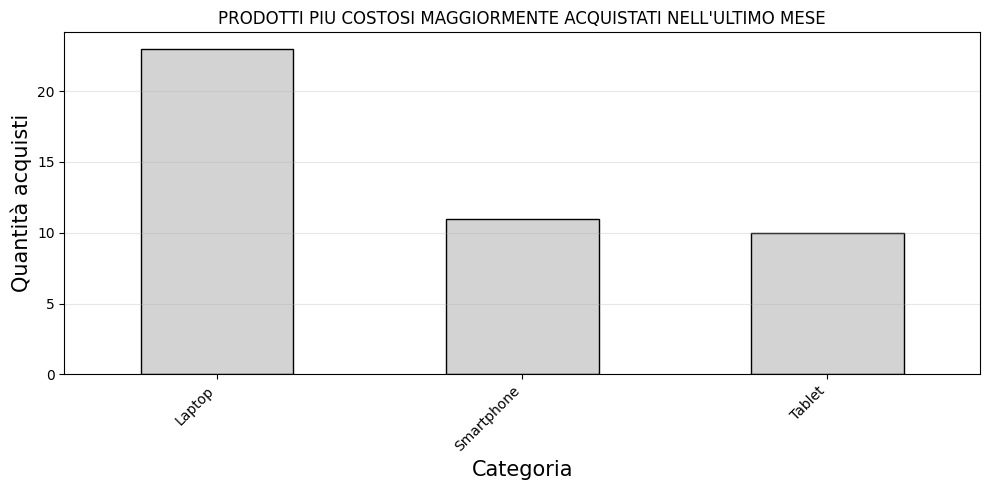

In [79]:
print("="*80)
print("PRODOTTI PIU COSTOSI MAGGIORMENTE ACQUISTATI NELL'ULTIMO MESE")
print("="*80)


risultato=df_resoconto.query("Prezzo > Prezzo.mean() and `Quantità` > `Quantità`.mean() and Mese==3")
display(risultato)

plt.figure(figsize=(10,5))
risultato["Categoria"].value_counts().plot(kind='bar', color='lightgrey', edgecolor="black")
plt.title("PRODOTTI PIU COSTOSI MAGGIORMENTE ACQUISTATI NELL'ULTIMO MESE")
plt.xlabel("Categoria", fontsize=15)
plt.ylabel("Quantità acquisti", fontsize=15)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()